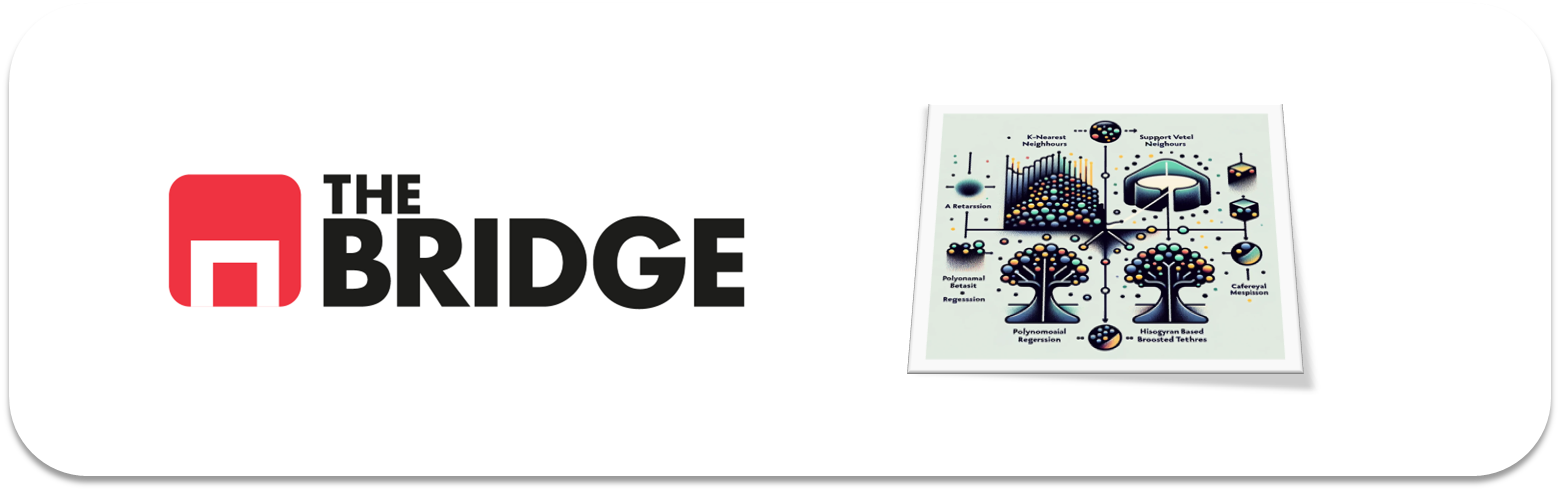

## PRACTICA OBLIGATORIA: **Otros Modelos Supervisados**

* La práctica obligatoria de esta unidad consiste en resolver un modelado de clasificación, incluyendo KNN entre los posibles modelos, y aplicando balanceado. Para ello utilizaremos un dataset que ya hemos empleado en los workout. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [ ]:
# Manipulación de datos
import pandas as pd
import numpy as np
from scipy import stats

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocesamiento
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import (
    StandardScaler, MinMaxScaler, RobustScaler,
    OneHotEncoder, LabelEncoder
)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

# Modelos
from sklearn.linear_model import (
    LinearRegression, LogisticRegression,
    Ridge, Lasso, ElasticNet
)
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestClassifier, RandomForestRegressor,
    GradientBoostingClassifier, GradientBoostingRegressor
)

# Métricas de regresión
from sklearn.metrics import (
    mean_squared_error, root_mean_squared_error,
    mean_absolute_error, r2_score
)

# Métricas de clasificación
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, precision_recall_curve
)

import warnings
warnings.filterwarnings('ignore')
pd.options.mode.copy_on_write = True

### #1. El problema y los datos

Vamos a volver al dataset con el que vimos la clasificación binaria con regresión logística, "Give me some credit", y nuestro objetivo es crear un modelo que nos permita predicir si una persona va a encontrarse en dificultades financieras en los dos próximos años. El dataset de partida lo puedes en contrar en el directorio data que acompaña al ejercicio. 

### #1.1
Cárgalo y, apoyándote en las herramientas y fuentes que consideres necesarias, haz una descripción textual de sus variables. Luego con ayuda de los datos, haz una clasificación inicial de sus variables en categóricas y numéricas.

In [2]:
df = pd.read_csv("./data/credit_npo.csv")
df.head()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,0,0.081892,37,0,0.070709,5656.0,12,1,0,0,0.0
1,0,0.023413,74,0,0.209197,4870.0,9,0,1,0,0.0
2,0,0.000000,43,0,0.080784,5000.0,2,0,0,0,2.0
3,0,0.492754,44,0,0.412735,7333.0,4,0,2,0,3.0
4,0,1.000000,63,0,0.000000,8333.0,3,0,0,0,1.0


In [3]:
def describe_df(df: pd.DataFrame) -> pd.DataFrame:
    """
    Genera un resumen estadístico descriptivo de un DataFrame.

    Argumentos:
        df (pd.DataFrame): DataFrame a analizar.

    Retorna:
        pd.DataFrame: DataFrame con una fila por columna del input y las
        siguientes columnas: 'tipo', 'porcentaje_nulos', 'valores_unicos',
        'porcentaje_cardinalidad'.
        Retorna None si el input no es un DataFrame válido.
    """
    
    # Comprobación de que si es un DataFrame
    if not isinstance(df, pd.DataFrame):
        print("Error: el objeto proporcionado no es un DataFrame.")
        return None

    # Crear el DataFrame resultado
    resultado = pd.DataFrame(index=df.columns)

    # Tipo de dato
    resultado["tipo"] = df.dtypes.astype(str)

    # Porcentaje de nulos
    resultado["porcentaje_nulos"] = (df.isna().mean() * 100).round(2)

    # Valores únicos
    resultado["valores_unicos"] = df.nunique()

    # Porcentaje de cardinalidad
    resultado["porcentaje_cardinalidad"] = ((df.nunique() / len(df)) * 100).round(2)


    return resultado


In [4]:
describe_df(df)

,tipo,porcentaje_nulos,valores_unicos,porcentaje_cardinalidad
SeriousDlqin2yrs,int64,0.00,2,0.02
RevolvingUtilizationOfUnsecuredLines,float64,0.00,10764,85.86
age,int64,0.00,78,0.62
NumberOfTime30-59DaysPastDueNotWorse,int64,0.00,10,0.08
DebtRatio,float64,0.00,11547,92.10
MonthlyIncome,float64,5.75,4167,33.24
NumberOfOpenCreditLinesAndLoans,int64,0.00,43,0.34
NumberOfTimes90DaysLate,int64,0.00,13,0.10
NumberRealEstateLoansOrLines,int64,0.00,16,0.13
NumberOfTime60-89DaysPastDueNotWorse,int64,0.00,8,0.06


In [5]:
df.describe()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,12537.000000,12537.000000,12537.000000,12537.000000,12537.000000,11816.000000,12537.000000,12537.000000,12537.000000,12537.000000,12360.000000
mean,0.068916,0.330359,52.079445,0.409588,1.902253,6864.815420,8.482332,0.259312,0.999202,0.228364,0.822087
std,0.253321,0.368148,15.077498,4.055787,9.122216,11855.905437,5.165422,4.035658,1.134325,4.018873,1.136802
min,0.000000,0.000000,21.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.030651,41.000000,0.000000,0.142268,3498.750000,5.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.163490,51.000000,0.000000,0.302025,5416.000000,8.000000,0.000000,1.000000,0.000000,0.000000
75%,0.000000,0.582219,62.000000,0.000000,0.506725,8300.000000,11.000000,0.000000,2.000000,0.000000,1.000000
max,1.000000,6.000000,101.000000,98.000000,99.000000,702500.000000,49.000000,98.000000,19.000000,98.000000,10.000000


 - 'SeriousDlquin2yrs' - TARGET - valores únicos 0 / 1 - problema de clasificación desbalanceado  
 - 'RevolvingUtilizationOfUnsecuredLines' - 0 - 6 - evalúa el nivel de riesgo
 - 'age' - edad
 - 'NumberOfTime30-59DaysPastDueNotWorse' - Cuántas veces el cliente ha tenido retrasos moderados (30–59 días) en sus pagos.
 - 'DebtRatio' - Qué parte de los ingresos mensuales de una persona se destina a pagar deudas y gastos financieros. - Numérica continua
 - 'MonthlyIncome' - Ingreso mensual 
 - 'NumberOfOpenCreditLinesAndLoans' - número total de líneas de crédito y préstamos abiertos  
 - 'NumberOfTimes90DaysLate' -  número de veces que la persona ha estado 90+ días de retraso en pagos.
 - 'NumberRealEstateLoansOrLines' -  número de préstamos o líneas de crédito relacionadas con bienes inmuebles (hipotecas, líneas HELOC…).
 - 'NumberOfTime60-89DaysPastDueNotWorse' - número de veces que la persona ha tenido retrasos de 60–89 días.
 - 'NumberOfDependents' - número de dependientes declarados (hijos, familiares a cargo).

In [6]:
df["SeriousDlqin2yrs"].value_counts()

SeriousDlqin2yrs
0    11673
1      864
Name: count, dtype: int64

In [7]:
from bootcampviztools import pinta_distribucion_categoricas, plot_combined_graphs

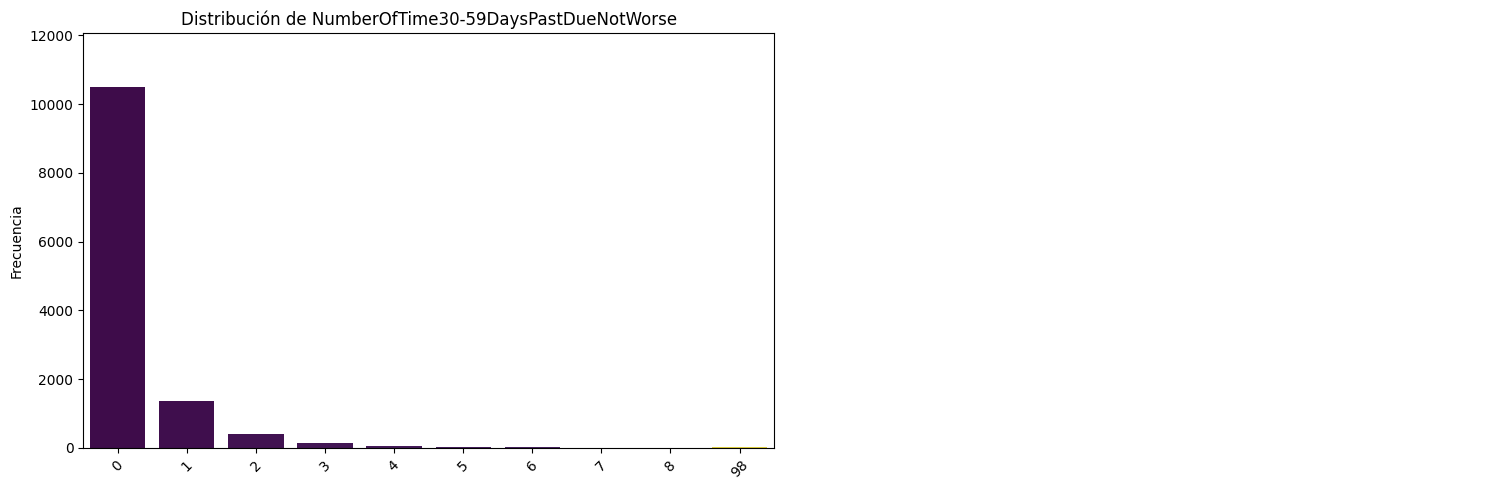

In [8]:
pinta_distribucion_categoricas(df, ['NumberOfTime30-59DaysPastDueNotWorse'])

In [9]:
df["NumberOfTime30-59DaysPastDueNotWorse"].value_counts()

NumberOfTime30-59DaysPastDueNotWorse
0     10500
1      1377
2       401
3       128
4        64
5        23
98       21
6        20
8         2
7         1
Name: count, dtype: int64

In [10]:
# los valores 98 vamos a pasarlos a NaN ya que son valores irreales o de los cuales no tenían información
df['NumberOfTime30-59DaysPastDueNotWorse'] = df['NumberOfTime30-59DaysPastDueNotWorse'].replace(98, np.nan)


In [11]:
df["NumberOfTimes90DaysLate"].value_counts()

NumberOfTimes90DaysLate
0     11839
1       412
2       147
3        55
4        33
98       21
5        14
6         6
7         4
8         3
10        1
9         1
13        1
Name: count, dtype: int64

In [12]:
# los valores 98 vamos a pasarlos a NaN ya que son valores irreales o de los cuales no tenían información
df['NumberOfTimes90DaysLate'] = df['NumberOfTimes90DaysLate'].replace(98, np.nan)

In [13]:
df['NumberOfTime60-89DaysPastDueNotWorse'].value_counts()

NumberOfTime60-89DaysPastDueNotWorse
0     11901
1       492
2        86
98       21
3        18
4        14
5         4
11        1
Name: count, dtype: int64

In [14]:
# los valores 98 vamos a pasarlos a NaN ya que son valores irreales o de los cuales no tenían información
df['NumberOfTime60-89DaysPastDueNotWorse'] = df['NumberOfTime60-89DaysPastDueNotWorse'].replace(98, np.nan)

In [15]:
df.columns

Index(['SeriousDlqin2yrs', 'RevolvingUtilizationOfUnsecuredLines', 'age',
       'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome',
       'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate',
       'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse',
       'NumberOfDependents'],
      dtype='str')

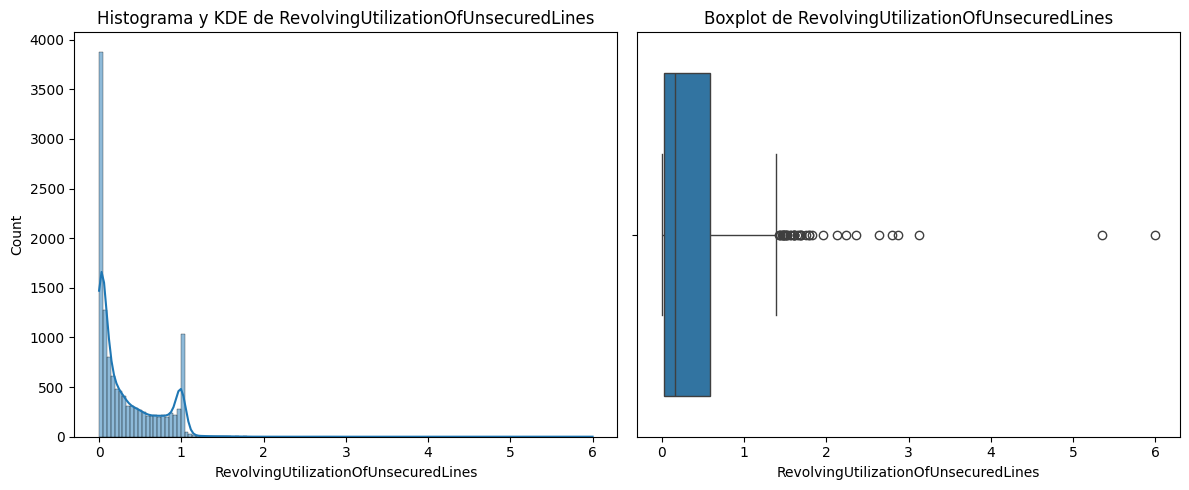

In [16]:
plot_combined_graphs(df, ['RevolvingUtilizationOfUnsecuredLines'])

In [17]:
df['RevolvingUtilizationOfUnsecuredLines'].nlargest(10)

10796    6.000000
12058    5.347652
7264     3.126246
8590     2.875622
6826     2.799050
1681     2.641791
4274     2.363982
6190     2.239601
7825     2.124728
8430     1.956811
Name: RevolvingUtilizationOfUnsecuredLines, dtype: float64

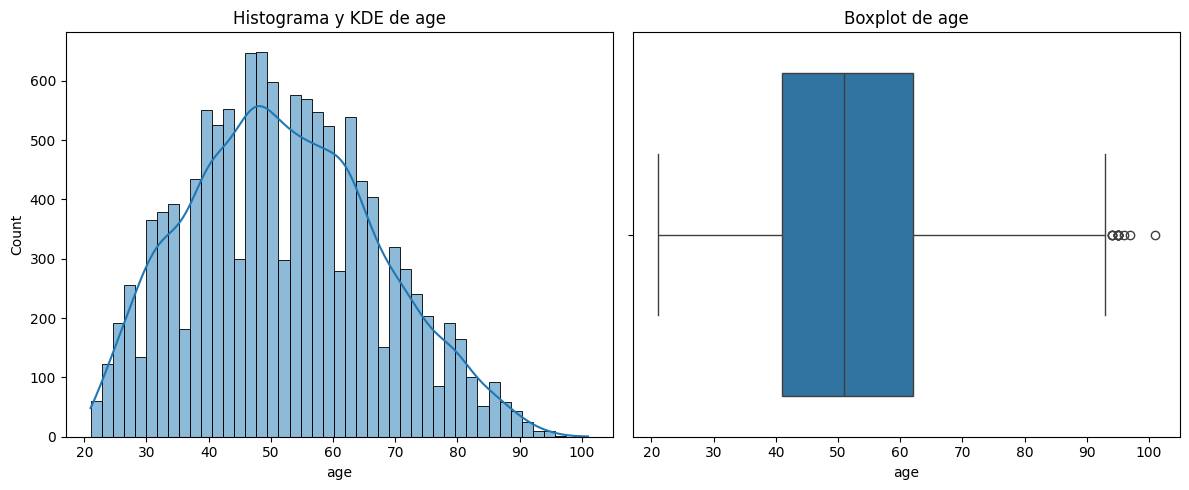

In [18]:
plot_combined_graphs(df, ['age'])

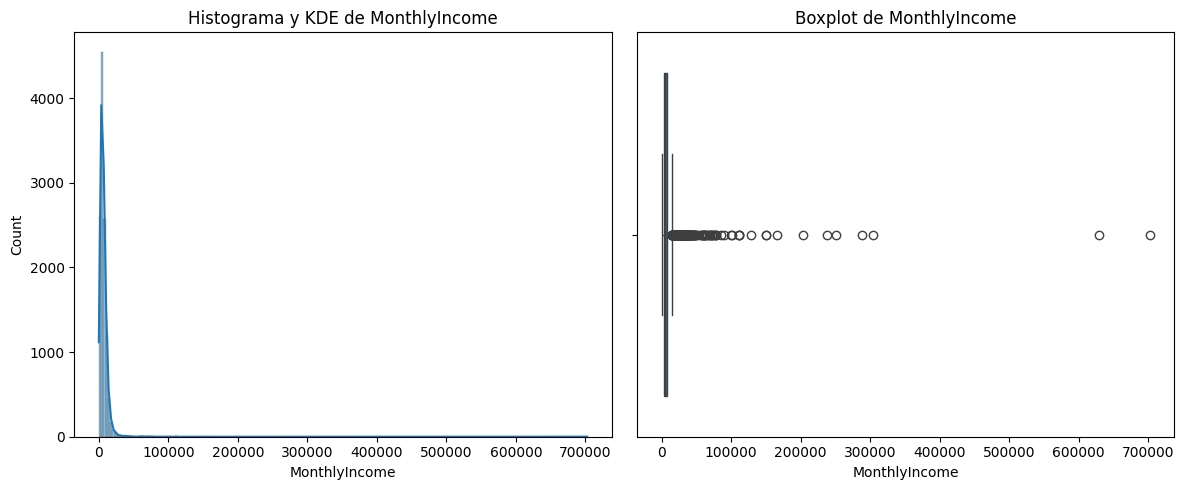

In [19]:
plot_combined_graphs(df, ['MonthlyIncome'])

In [20]:
df['MonthlyIncome'].nlargest(10)

3291    702500.0
5733    629000.0
2024    304000.0
4587    287662.0
2313    251608.0
4563    237490.0
2201    203500.0
4642    166666.0
5477    150000.0
9134    150000.0
Name: MonthlyIncome, dtype: float64

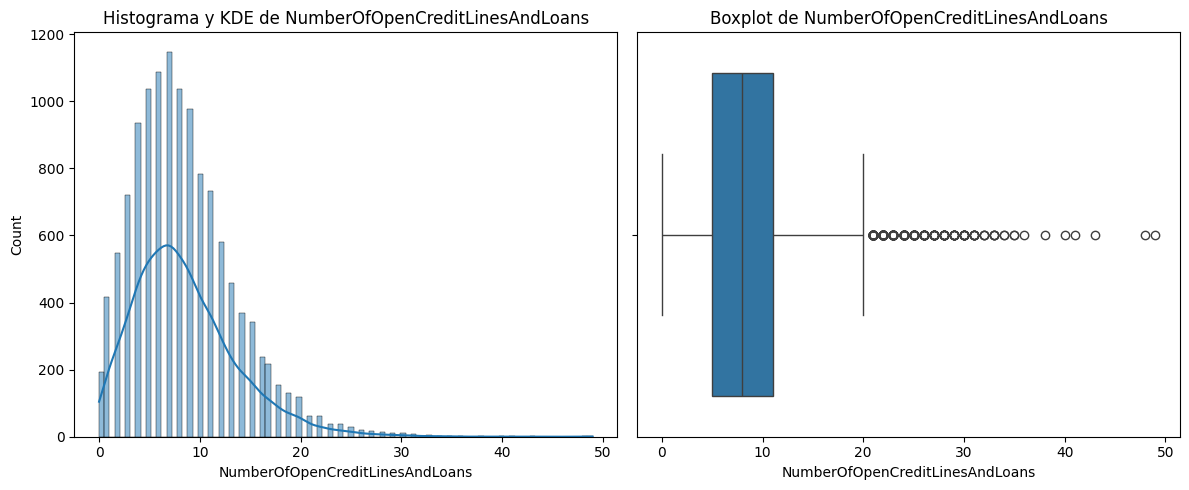

In [21]:
plot_combined_graphs(df, ['NumberOfOpenCreditLinesAndLoans'])

### #1.2
¿Qué tipo de problema estamos tratando? ¿Cuál es la variable target?

Estamos tratando un problema de clasificación, nuestra variable TARGET es SeriousDlquin2yrs - Desbalanceada

### #1.3
Pinta la distribución de frecuencias del target y coméntala

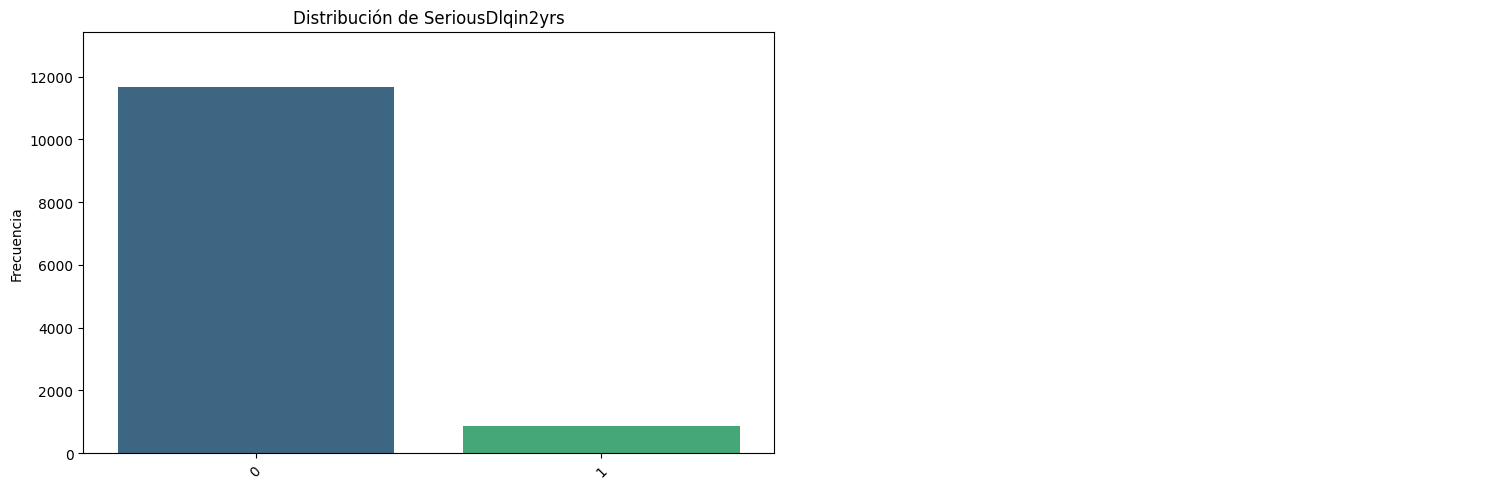

In [22]:
pinta_distribucion_categoricas(df, ['SeriousDlqin2yrs'])

### #2 Modelado

Realiza un proceso completo de modelado hasta dar con el mejor modelo de los que hayas escogido (emplea al menos 3, y uno tiene que ser KNN). Aplica las técnicas que creas necesarias para obtener el mejor resultado (suponiendo que este después de hablar con el negocio es el recall medio, para tener un compromiso entre las dos clases). Para comparar modelos emplea validación cruzada antes de optimización y luego ajusta los hiperparámetros del mejor modelo. Evalúa este y haz un pequeño análisis de errores.

In [23]:
TARGET = 'SeriousDlqin2yrs'  # ← Cambia esto por el nombre de tu columna objetivo

X = df.drop(columns=[TARGET])
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,       # 20 % para test
    random_state=42,     # Fija la semilla → resultados reproducibles
    stratify=y           # Descomentar en clasificación con clases desbalanceadas
)

print(f"Train: {X_train.shape[0]} filas  ({X_train.shape[0]/len(df)*100:.0f} %)")
print(f"Test:  {X_test.shape[0]} filas  ({X_test.shape[0]/len(df)*100:.0f} %)")

Train: 10029 filas  (80 %)
Test:  2508 filas  (20 %)


In [24]:
# Tipos de datos
print(X_train.dtypes)
print()

# Valores faltantes
missing = X_train.isna().sum()
missing_pct = (missing / len(X_train) * 100).round(1)
resumen = pd.DataFrame({'count': missing, '%': missing_pct})
print(resumen[resumen['count'] > 0].sort_values('%', ascending=False))
print()

# Duplicados
print(f"Duplicados: {X_train.duplicated().sum()}")

RevolvingUtilizationOfUnsecuredLines    float64
age                                       int64
NumberOfTime30-59DaysPastDueNotWorse    float64
DebtRatio                               float64
MonthlyIncome                           float64
NumberOfOpenCreditLinesAndLoans           int64
NumberOfTimes90DaysLate                 float64
NumberRealEstateLoansOrLines              int64
NumberOfTime60-89DaysPastDueNotWorse    float64
NumberOfDependents                      float64
dtype: object

                                      count    %
MonthlyIncome                           583  5.8
NumberOfDependents                      141  1.4
NumberOfTime30-59DaysPastDueNotWorse     14  0.1
NumberOfTimes90DaysLate                  14  0.1
NumberOfTime60-89DaysPastDueNotWorse     14  0.1

Duplicados: 11


In [25]:
# Eliminamos los duplicados
X_train = X_train.drop_duplicates()
y_train = y_train.loc[X_train.index]


In [26]:
filas_con_mas_de_2_nulos = df[df.isnull().sum(axis=1) > 2]
filas_con_mas_de_2_nulos

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
32,1,1.0,43,NaN,96.000000,NaN,0,NaN,0,NaN,0.0
74,0,1.0,26,NaN,0.000000,NaN,0,NaN,0,NaN,0.0
483,1,1.0,44,NaN,0.037367,2916.0,0,NaN,0,NaN,2.0
524,0,1.0,29,NaN,0.000000,NaN,0,NaN,0,NaN,0.0
1123,1,1.0,25,NaN,54.000000,NaN,0,NaN,0,NaN,0.0
1182,0,1.0,25,NaN,0.020344,1916.0,0,NaN,0,NaN,0.0
3803,1,1.0,25,NaN,0.000000,640.0,0,NaN,0,NaN,0.0
4232,0,1.0,28,NaN,0.000000,NaN,0,NaN,0,NaN,NaN
4312,0,1.0,22,NaN,0.000000,NaN,0,NaN,0,NaN,NaN
4722,1,1.0,51,NaN,0.000000,7500.0,0,NaN,0,NaN,0.0


In [32]:
X_train = df.dropna(thresh=df.shape[1] - 2)
X_test = df.dropna(thresh=df.shape[1] - 2)

In [36]:
X_train.isnull().sum()

SeriousDlqin2yrs                          0
RevolvingUtilizationOfUnsecuredLines      0
age                                       0
NumberOfTime30-59DaysPastDueNotWorse      0
DebtRatio                                 0
MonthlyIncome                           710
NumberOfOpenCreditLinesAndLoans           0
NumberOfTimes90DaysLate                   0
NumberRealEstateLoansOrLines              0
NumberOfTime60-89DaysPastDueNotWorse      0
NumberOfDependents                      175
dtype: int64

In [31]:
X_train.describe()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,12516.000000,12516.000000,12516.000000,12516.000000,12516.000000,11806.000000,12516.000000,12516.000000,12516.000000,12516.000000,12341.000000
mean,0.068153,0.329236,52.109060,0.245845,1.893435,6868.595291,8.496564,0.095318,1.000879,0.064318,0.823191
std,0.252018,0.367433,15.063271,0.685011,9.078800,11860.060390,5.158044,0.506710,1.134537,0.333413,1.137194
min,0.000000,0.000000,21.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.030540,41.000000,0.000000,0.143279,3500.000000,5.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.162768,51.000000,0.000000,0.302373,5417.000000,8.000000,0.000000,1.000000,0.000000,0.000000
75%,0.000000,0.578673,62.000000,0.000000,0.506985,8302.500000,11.000000,0.000000,2.000000,0.000000,1.000000
max,1.000000,6.000000,101.000000,8.000000,99.000000,702500.000000,49.000000,13.000000,19.000000,11.000000,10.000000


In [29]:
# Porcentaje de missings por columna
missing_pct = X_train.isna().mean().mul(100).round(1)
print(missing_pct[missing_pct > 0].sort_values(ascending=False))

# Imputación con mediana usando sklearn (fit en train, transform en ambos)
cols_num = X_train.select_dtypes('number').columns.tolist()

imputer = SimpleImputer(strategy='median')
X_train[cols_num] = imputer.fit_transform(X_train[cols_num])  # fit + transform
X_test[cols_num]  = imputer.transform(X_test[cols_num])        # solo transform

MonthlyIncome                           5.7
NumberOfDependents                      1.4
NumberOfTime30-59DaysPastDueNotWorse    0.1
NumberOfTimes90DaysLate                 0.1
NumberOfTime60-89DaysPastDueNotWorse    0.1
dtype: float64


In [30]:
X_train.isnull().sum()

RevolvingUtilizationOfUnsecuredLines    0
age                                     0
NumberOfTime30-59DaysPastDueNotWorse    0
DebtRatio                               0
MonthlyIncome                           0
NumberOfOpenCreditLinesAndLoans         0
NumberOfTimes90DaysLate                 0
NumberRealEstateLoansOrLines            0
NumberOfTime60-89DaysPastDueNotWorse    0
NumberOfDependents                      0
dtype: int64

In [31]:
X_test.isnull().sum()

RevolvingUtilizationOfUnsecuredLines    0
age                                     0
NumberOfTime30-59DaysPastDueNotWorse    0
DebtRatio                               0
MonthlyIncome                           0
NumberOfOpenCreditLinesAndLoans         0
NumberOfTimes90DaysLate                 0
NumberRealEstateLoansOrLines            0
NumberOfTime60-89DaysPastDueNotWorse    0
NumberOfDependents                      0
dtype: int64

In [ ]:
# Calculamos el pvalue mediante el método Anova de las variables numéricas (target categórica)

In [32]:
import scipy.stats as stats

target = 'SeriousDlqin2yrs'

# Seleccionamos solo columnas numéricas
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
num_cols = num_cols.drop(target)  # quitamos el target

resultados = []

for col in num_cols:
    # Creamos los dos grupos según el target
    grupo_0 = df[df[target] == 0][col].dropna()
    grupo_1 = df[df[target] == 1][col].dropna()

    # ANOVA con desempaquetado *
    f_val, p_val = stats.f_oneway(grupo_0, grupo_1)

    resultados.append({
        'feature': col,
        'F_value': f_val,
        'p_value': p_val
    })

anova_df = pd.DataFrame(resultados).sort_values('p_value')
anova_df


,feature,F_value,p_value
6,NumberOfTimes90DaysLate,1749.362225,0.000000e+00
0,RevolvingUtilizationOfUnsecuredLines,1055.156176,2.704137e-222
2,NumberOfTime30-59DaysPastDueNotWorse,868.152782,1.518214e-184
8,NumberOfTime60-89DaysPastDueNotWorse,849.513980,9.400838e-181
1,age,169.176208,1.986564e-38
9,NumberOfDependents,27.400642,1.680911e-07
5,NumberOfOpenCreditLinesAndLoans,7.402931,6.520770e-03
3,DebtRatio,6.002040,1.430295e-02
4,MonthlyIncome,5.449501,1.959060e-02
7,NumberRealEstateLoansOrLines,0.894386,3.443097e-01


In [33]:
# Seleccionar features relevantes según ANOVA (p < 0.05)
features_num_sel = anova_df[anova_df["p_value"] < 0.05]["feature"].tolist()
features_num_sel

['NumberOfTimes90DaysLate',
 'RevolvingUtilizationOfUnsecuredLines',
 'NumberOfTime30-59DaysPastDueNotWorse',
 'NumberOfTime60-89DaysPastDueNotWorse',
 'age',
 'NumberOfDependents',
 'NumberOfOpenCreditLinesAndLoans',
 'DebtRatio',
 'MonthlyIncome']

“Según ANOVA, todas las variables numéricas presentan diferencias significativas entre las clases del target (p < 0.05). Por tanto, rechazamos la hipótesis nula en todos los casos y concluimos que cada una de estas variables está estadísticamente asociada a nuestra target.”

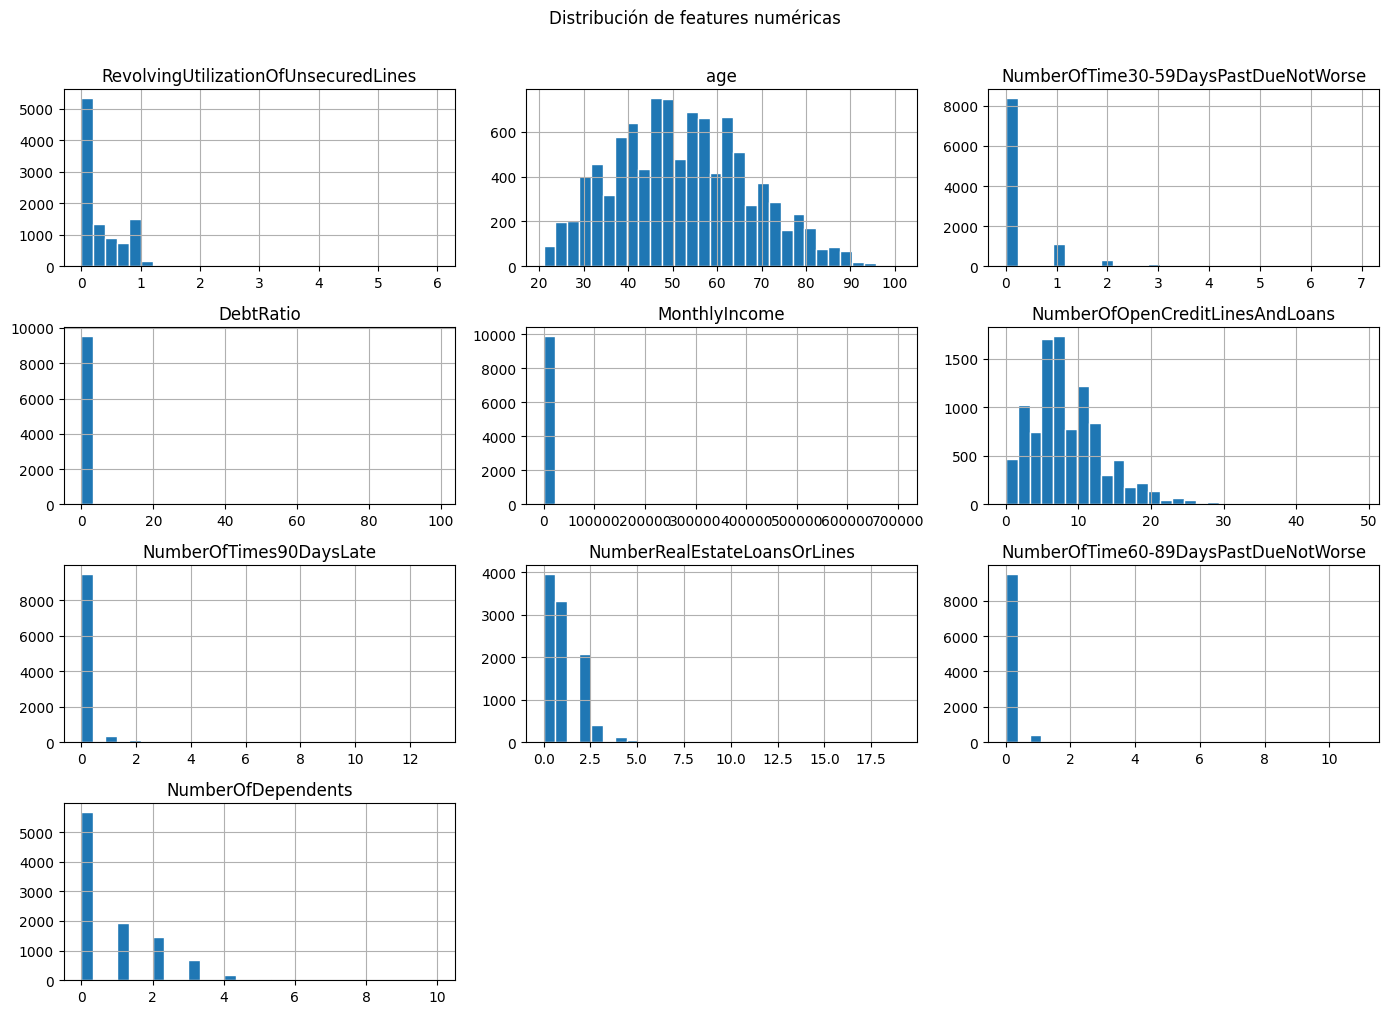

Skewness por feature:
MonthlyIncome                           34.854260
NumberOfTime60-89DaysPastDueNotWorse     9.195894
NumberOfTimes90DaysLate                  8.753517
DebtRatio                                6.947789
NumberOfTime30-59DaysPastDueNotWorse     3.904497
NumberRealEstateLoansOrLines             2.579743
RevolvingUtilizationOfUnsecuredLines     1.583261
NumberOfDependents                       1.426956
NumberOfOpenCreditLinesAndLoans          1.114536
age                                      0.251786


In [35]:
X_train.select_dtypes('number').hist(figsize=(14, 10), bins=30, edgecolor='white')
plt.suptitle('Distribución de features numéricas', y=1.01)
plt.tight_layout()
plt.show()

# Skewness de cada feature numérica
skew = X_train.select_dtypes('number').skew().sort_values(key=abs, ascending=False)
print("Skewness por feature:")
print(skew.to_string())

In [37]:
features_log = [
    'MonthlyIncome',
    'NumberOfTime60-89DaysPastDueNotWorse',
    'NumberOfTimes90DaysLate',
    'DebtRatio',
    'NumberOfTime30-59DaysPastDueNotWorse',
    'NumberRealEstateLoansOrLines',
    'RevolvingUtilizationOfUnsecuredLines',
    'NumberOfDependents',
    'NumberOfOpenCreditLinesAndLoans'
]

for col in features_log:
    X_train[col] = np.log1p(X_train[col])
    X_test[col]  = np.log1p(X_test[col])


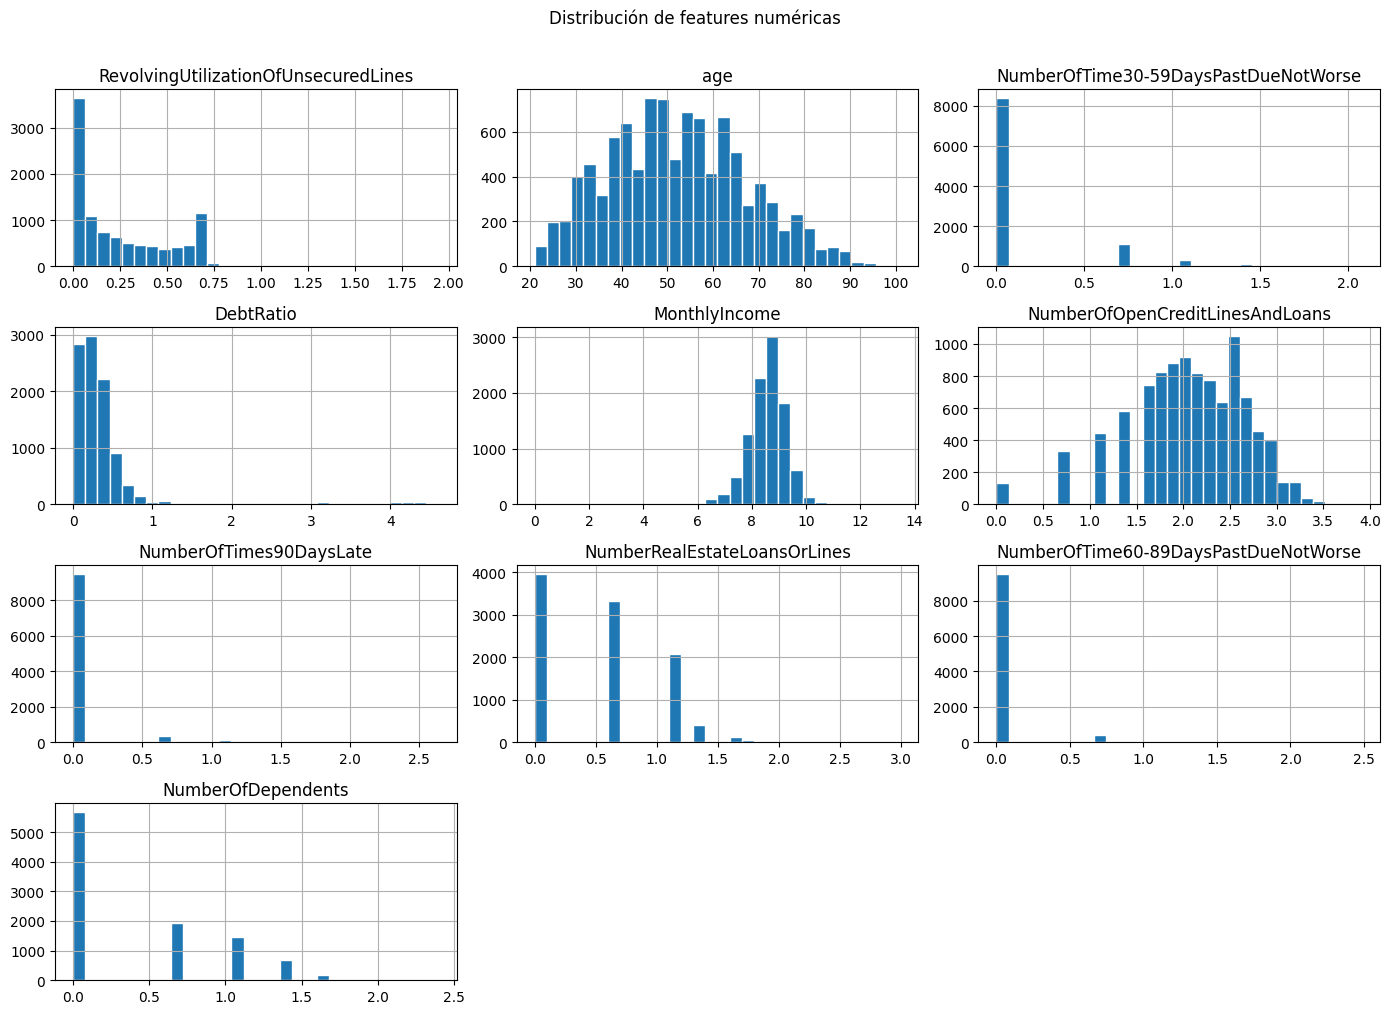

In [ ]:
# despues de aplicar la transformación

X_train.select_dtypes('number').hist(figsize=(14, 10), bins=30, edgecolor='white')
plt.suptitle('Distribución de features numéricas', y=1.01)
plt.tight_layout()
plt.show()

In [39]:
X_train[features_log].skew().sort_values()

MonthlyIncome                          -3.367689
NumberOfOpenCreditLinesAndLoans        -0.779171
NumberRealEstateLoansOrLines            0.297366
NumberOfDependents                      0.724424
RevolvingUtilizationOfUnsecuredLines    0.769179
NumberOfTime30-59DaysPastDueNotWorse    2.462061
DebtRatio                               4.197752
NumberOfTime60-89DaysPastDueNotWorse    4.966285
NumberOfTimes90DaysLate                 5.119146
dtype: float64

In [ ]:
# Escalado de las variables

num_cols = X_train.select_dtypes('number').columns.tolist()

scaler = StandardScaler()   # ← Cambiar según la situación

X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])  # fit + transform
X_test_scaled[num_cols]  = scaler.transform(X_test[num_cols])        # solo transform

In [41]:
X_train.describe()

,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,1.001800e+04,1.001800e+04,1.001800e+04,1.001800e+04,1.001800e+04,1.001800e+04,1.001800e+04,1.001800e+04,1.001800e+04,1.001800e+04
mean,7.021734e-17,-9.415507e-17,6.667101e-17,-4.113743e-17,7.241606e-16,2.950547e-16,1.063899e-17,-5.390422e-17,7.801927e-18,-1.418532e-18
std,1.000050e+00,1.000050e+00,1.000050e+00,1.000050e+00,1.000050e+00,1.000050e+00,1.000050e+00,1.000050e+00,1.000050e+00,1.000050e+00
min,-9.996563e-01,-2.059554e+00,-4.112591e-01,-6.082044e-01,-1.016812e+01,-3.444683e+00,-2.204667e-01,-1.103305e+00,-2.189392e-01,-8.072192e-01
25%,-8.810364e-01,-7.335377e-01,-4.112591e-01,-4.125058e-01,-4.373978e-01,-4.920548e-01,-2.204667e-01,-1.103305e+00,-2.189392e-01,-8.072192e-01
50%,-3.997747e-01,-7.052980e-02,-4.112591e-01,-2.187236e-01,7.049617e-02,1.761083e-01,-2.204667e-01,2.676836e-01,-2.189392e-01,-8.072192e-01
75%,8.221617e-01,6.587789e-01,-4.112591e-01,-6.699744e-03,5.349803e-01,6.501776e-01,-2.204667e-01,1.069661e+00,-2.189392e-01,4.861368e-01
max,6.726623e+00,3.244510e+00,5.614465e+00,6.141949e+00,5.864401e+00,3.001913e+00,1.152755e+01,4.822009e+00,1.346719e+01,3.667058e+00


# 1. REGRESIÓN LOGÍSTICA

In [ ]:
# Prefiero predecir que alguien NO me va a pagar aunque luego sí lo haga, antes que predecir que alguien me va a pagar y luego no lo haga.

# El falso negativo es el error más grave.

# La métrica clave es el recall de la clase 1.

In [54]:
# Creamos el modelo de regresión logística

from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(max_iter=500, class_weight='balanced')

# Entrenamos el modelo

log_reg.fit(X_train, y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

              precision    recall  f1-score   support

           0       0.97      0.80      0.88      2335
           1       0.21      0.72      0.33       173

    accuracy                           0.80      2508
   macro avg       0.59      0.76      0.60      2508
weighted avg       0.92      0.80      0.84      2508



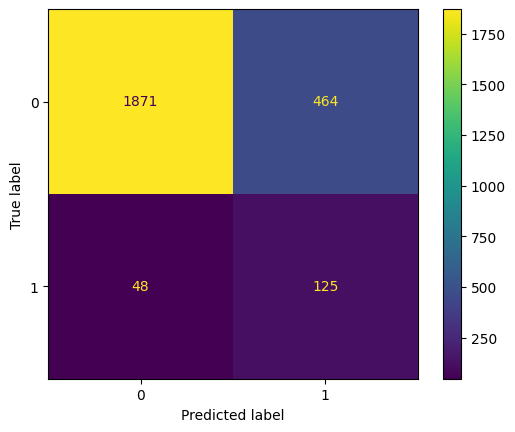

In [55]:
# Sacamos las prediciones frente a test
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

y_pred = log_reg.predict(X_test)

print(classification_report(y_test, y_pred))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)


In [56]:
grid_logreg = {
    'penalty':  ['l1', 'l2'],
    'C':        [0.01, 0.1, 0.5, 1.0, 5.0, 10.0],
    'max_iter': [100, 500],
    'solver':   ['liblinear']
}

model = LogisticRegression(solver='liblinear', class_weight='balanced') # muy importante para clases desbalanceadas


grid = GridSearchCV(
    estimator=model,
    param_grid=grid_logreg,
    cv=5,
    scoring='recall',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print('Mejores hiperparámetros:', grid.best_params_)
print('Mejor score en CV:',       round(grid.best_score_, 3))

best_model = grid.best_estimator_

Mejores hiperparámetros: {'C': 0.01, 'max_iter': 100, 'penalty': 'l1', 'solver': 'liblinear'}
Mejor score en CV: 0.762


              precision    recall  f1-score   support

           0       0.98      0.79      0.87      2335
           1       0.21      0.74      0.32       173

    accuracy                           0.79      2508
   macro avg       0.59      0.77      0.60      2508
weighted avg       0.92      0.79      0.84      2508



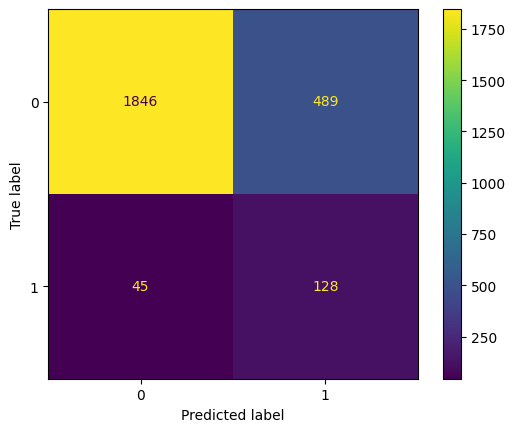

In [57]:
# Evaluación del modelo con los mejores hiperparámetros

y_pred = best_model.predict(X_test)

print(classification_report(y_test, y_pred))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)


# 2. RANDOM FOREST

In [46]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    random_state=42,
    class_weight='balanced'   # MUY importante por el desbalanceo
)

rf.fit(X_train, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

              precision    recall  f1-score   support

           0       0.94      0.99      0.97      2335
           1       0.60      0.16      0.25       173

    accuracy                           0.93      2508
   macro avg       0.77      0.58      0.61      2508
weighted avg       0.92      0.93      0.92      2508



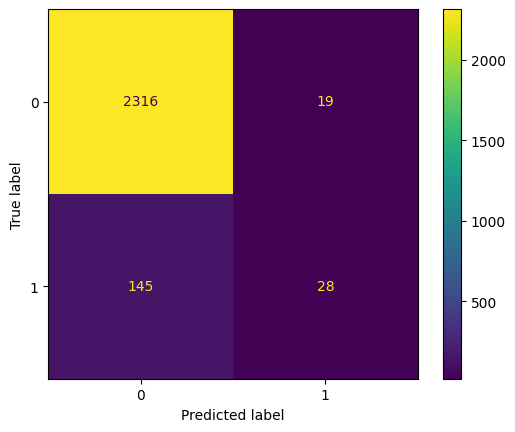

In [47]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

y_pred = rf.predict(X_test)

print(classification_report(y_test, y_pred))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)


In [ ]:
# Con validación cruzada hacemos la predicción frente al train

from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    rf,
    X_train,
    y_train,
    cv=5,
    scoring='recall'
)

scores.mean(), scores.std()

(np.float64(0.18138157198772875), np.float64(0.022636669701317568))

In [59]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

param_dist = {
    'n_estimators': randint(100, 600),  #randint genera números enteros aleatorios dentro de este rango
    'max_depth': [None, 5, 10, 20, 30],
    'min_samples_split': randint(2, 20),
    'min_samples_leaf': randint(1, 10),
    'max_features': ['sqrt', 'log2', None],
    'class_weight': ['balanced']
}

rf = RandomForestClassifier(random_state=42)

random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=40,                 # 40 combinaciones aleatorias
    scoring='recall', 
    cv=5,
    n_jobs=-1,
    random_state=42
)

random_search.fit(X_train, y_train)

print("Mejores hiperparámetros:", random_search.best_params_)
print("Mejor recall:", random_search.best_score_)


Mejores hiperparámetros: {'class_weight': 'balanced', 'max_depth': 5, 'max_features': 'log2', 'min_samples_leaf': 2, 'min_samples_split': 13, 'n_estimators': 261}
Mejor recall_macro: 0.7532635142282873


In [60]:
best_rf = random_search.best_estimator_
best_rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",261
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",13
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'log2'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

              precision    recall  f1-score   support

           0       0.98      0.78      0.87      2335
           1       0.20      0.75      0.32       173

    accuracy                           0.78      2508
   macro avg       0.59      0.77      0.60      2508
weighted avg       0.92      0.78      0.83      2508



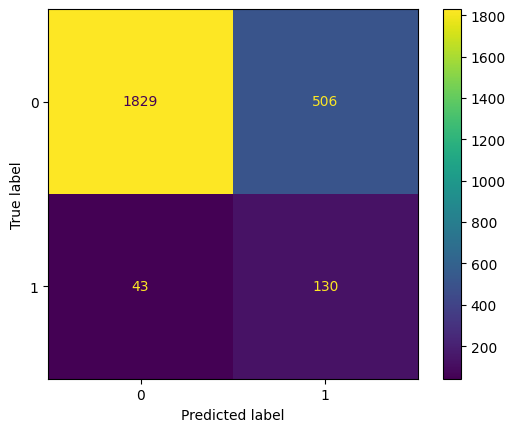

In [61]:
y_pred_final = best_rf.predict(X_test)

print(classification_report(y_test, y_pred_final))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_final)


# 3. MODELO KNN

In [62]:
# Creamos el baseline para el modelo KNN y lo entrenamos
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()

knn.fit(X_train, y_train)


,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [63]:
from sklearn.model_selection import cross_val_score

scores_knn = cross_val_score(
    knn,
    X_train,
    y_train,
    cv=5,
    scoring='recall'
)

scores_knn.mean(), scores_knn.std()


(np.float64(0.16399026763990268), np.float64(0.020167406393739533))

In [64]:
grid_knn = {
    'n_neighbors': [3, 5, 7, 9, 11, 15, 21],
    'weights': ['uniform', 'distance'],
    'p': [1, 2]   # Manhattan vs Euclídea
}

from sklearn.model_selection import GridSearchCV

knn = KNeighborsClassifier()

grid = GridSearchCV(
    estimator=knn,
    param_grid=grid_knn,
    cv=5,
    scoring='recall',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Mejores hiperparámetros:", grid.best_params_)
print("Mejor recall:", grid.best_score_)


Mejores hiperparámetros: {'n_neighbors': 3, 'p': 1, 'weights': 'distance'}
Mejor recall: 0.18867026340844179


              precision    recall  f1-score   support

           0       0.95      0.97      0.96      2335
           1       0.43      0.25      0.32       173

    accuracy                           0.93      2508
   macro avg       0.69      0.61      0.64      2508
weighted avg       0.91      0.93      0.92      2508



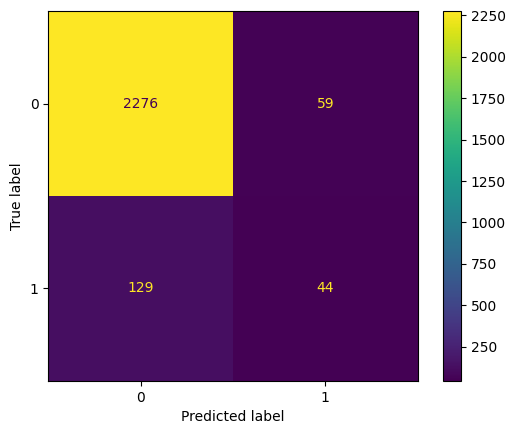

In [65]:
best_knn = grid.best_estimator_

y_pred_knn = best_knn.predict(X_test)

print(classification_report(y_test, y_pred_knn))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_knn)


# 4. XGBoost

              precision    recall  f1-score   support

           0       0.94      0.98      0.96      2335
           1       0.47      0.20      0.28       173

    accuracy                           0.93      2508
   macro avg       0.70      0.59      0.62      2508
weighted avg       0.91      0.93      0.92      2508



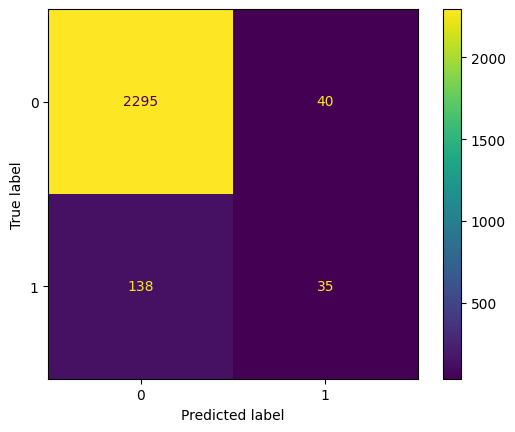

In [69]:
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV


# Creación de la baseline

xgb = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    tree_method='hist',
    random_state=42
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

print(classification_report(y_test, y_pred_xgb))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_xgb)


In [70]:
from scipy.stats import randint, uniform

param_dist = {
    'n_estimators': randint(200, 600),
    'max_depth': randint(2, 10),
    'learning_rate': uniform(0.01, 0.2),
    'subsample': uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4),
    'gamma': uniform(0, 5),
    'min_child_weight': randint(1, 10),
    'scale_pos_weight': [1, 2, 5, 10]   # MUY importante para desbalanceo
}

random_search_xgb = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=40,
    scoring='recall',
    cv=5,
    n_jobs=-1,
    random_state=42
)

random_search_xgb.fit(X_train, y_train)

print("Mejores hiperparámetros:", random_search_xgb.best_params_)
print("Mejor recall:", random_search_xgb.best_score_)

Mejores hiperparámetros: {'colsample_bytree': np.float64(0.8439986631130484), 'gamma': np.float64(4.165974558680822), 'learning_rate': np.float64(0.04467293070155442), 'max_depth': 2, 'min_child_weight': 4, 'n_estimators': 249, 'scale_pos_weight': 10, 'subsample': np.float64(0.902144564127061)}
Mejor recall: 0.6836348249233046


              precision    recall  f1-score   support

           0       0.97      0.85      0.91      2335
           1       0.25      0.69      0.37       173

    accuracy                           0.84      2508
   macro avg       0.61      0.77      0.64      2508
weighted avg       0.92      0.84      0.87      2508



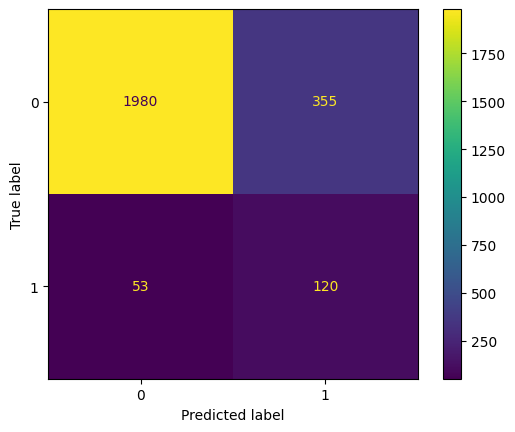

In [71]:
best_xgb = random_search_xgb.best_estimator_

y_pred_xgb = best_xgb.predict(X_test)

print(classification_report(y_test, y_pred_xgb))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_xgb)


# 5. CatBoost

              precision    recall  f1-score   support

           0       0.97      0.91      0.94      2335
           1       0.33      0.58      0.42       173

    accuracy                           0.89      2508
   macro avg       0.65      0.75      0.68      2508
weighted avg       0.92      0.89      0.90      2508



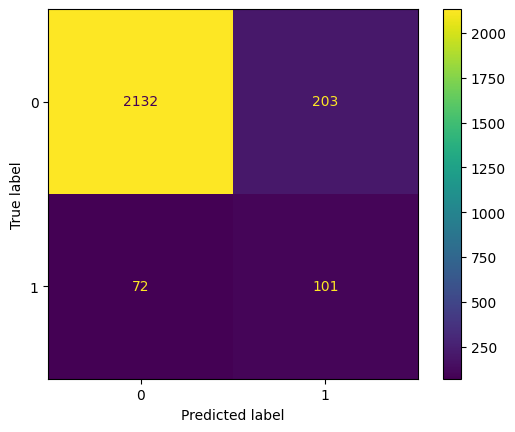

In [74]:
from catboost import CatBoostClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

cat = CatBoostClassifier(
    loss_function='Logloss',
    eval_metric='Recall',
    class_weights=[1, 10],   # MUY importante para desbalanceo
    random_seed=42,
    verbose=0
)

cat.fit(X_train, y_train)

y_pred_cat = cat.predict(X_test)

print(classification_report(y_test, y_pred_cat))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_cat)


In [77]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

model_names = ["Logistic Regression","DecisionTree","Random Forest","XGBoost","LightGBM","CatBoost"]
lr_clf = LogisticRegression(max_iter = 10000)
tree_clf = DecisionTreeClassifier(random_state= 42)
rf_clf = RandomForestClassifier(random_state= 42)
xgb_clf = XGBClassifier(random_state = 42)
lgb_clf = LGBMClassifier(random_state= 42, verbose = -100)
cat_clf = CatBoostClassifier(random_state= 42, verbose = False)

model_set = [lr_clf, tree_clf, rf_clf, xgb_clf, lgb_clf, cat_clf]


In [ ]:
# No optimizo ninguno de los parámetros, y utilizo el método de CV
metricas_cv = {}
valores = []
for nombre,modelo in zip(model_names, model_set):
    print(modelo)
    if nombre != "Logistic Regression":
        metricas_cv[nombre] = cross_val_score(modelo, X_train, y_train, cv = 3, scoring = "accuracy")
    else:
        metricas_cv[nombre] = cross_val_score(modelo, X_train_escaled, y_train, cv = 3, scoring = "accuracy")
    valores.append(np.mean(metricas_cv[nombre]))
ganador = list(metricas_cv.keys())[np.argmax(valores)]

LogisticRegression(max_iter=10000)


NameError: name 'X_train_scaled' is not defined